# Kernel Machines (Theory and Examples)

## 1. Kernel Trick Revisited

In many learning problems the relationship between input and output is typically **nonlinear**.  

A classical idea is to map the data into a higher dimensional feature space

$$
\phi : \mathcal X \rightarrow \mathcal H
$$

and then apply a **linear model** there.

$$
f(x) = \langle w , \phi(x) \rangle
$$

However, the feature space may be **very high dimensional or even infinite dimensional**.

The key observation is that many algorithms depend only on **inner products**

$$
\langle \phi(x), \phi(x') \rangle
$$

If we can compute this quantity directly, we never need to compute the feature map itself.

This leads to the **kernel trick**.

$$
k(x,x') = \langle \phi(x), \phi(x') \rangle
$$

The function $k$ is called a **kernel**.

Typical examples:

- Linear kernel  
- Polynomial kernel  
- Gaussian (RBF) kernel

Kernel methods allow us to construct **nonlinear models while keeping linear algorithms**.

---

### Positive Definite Kernels

A function

$$
k : \mathcal X \times \mathcal X \to \mathbb{R}
$$

is called a **positive definite kernel** if for every finite set of points $x_1,\dots,x_n$
the **Gram matrix**
$$
K_{ij} = k(x_i,x_j)
$$
is positive semidefinite.

Equivalently,
$$
\sum_{i,j=1}^n c_i c_j k(x_i,x_j) \ge 0
$$

for all $c_1,\dots,c_n \in \mathbb{R}$.

Positive definiteness guarantees that the kernel corresponds to an inner product in some feature space.

#### Examples of kernels

**Linear kernel**

$$
k(x,x') = x^\top x'
$$

**Polynomial kernel**

$$
k(x,x') = (x^\top x' + c)^d
$$

**Gaussian (RBF) kernel**

$$
k(x,x') =
\exp\!\left(
-\frac{\|x-x'\|^2}{2\sigma^2}
\right)
$$

The Gaussian kernel corresponds to an **infinite dimensional feature space**.

---

### Reproducing Kernel Hilbert Spaces

Every positive definite kernel defines a Hilbert space of functions called a **Reproducing Kernel Hilbert Space (RKHS)**.

This space has two key properties:

1. Kernel sections belong to the space: For every $x$,
$$
k(x,\cdot) \in \mathcal H
$$

2. Reproducing property: For every $f \in \mathcal H$,
$$
f(x) = \langle f , k(x,\cdot) \rangle_{\mathcal H}
$$

This means that **evaluation of a function can be written as an inner product**.

Hence the name *reproducing kernel*.

#### Intuition

Functions in the RKHS can be viewed as linear combinations of kernel functions

$$
f(x) =
\sum_{i=1}^n
\alpha_i k(x,x_i)
$$

Thus kernels act as **basis functions centered at data points**.
  
### Representer Theorem

Many learning problems can be formulated as **regularized empirical risk minimization** in an RKHS.

Let $\mathcal H$ be a reproducing kernel Hilbert space with kernel $k$, and let
$(x_1,y_1),\dots,(x_n,y_n)$ be training data.

Consider the optimization problem

$$
\min_{f \in \mathcal H}
\sum_{i=1}^{n} L\!\left(y_i,f(x_i)\right)
+
\lambda \, \|f\|_{\mathcal H}^2
$$

where

- $L$ is a loss function
- $\lambda>0$ is a regularization parameter.

---

**Representer Theorem:** Any minimizer $f^*$ of the above problem admits a representation of the form

$$
f^*(x)
=
\sum_{i=1}^{n}
\alpha_i\, k(x,x_i)
$$

for some coefficients $\alpha_1,\dots,\alpha_n \in \mathbb{R}$.

---

#### Interpretation

The theorem states that although the optimization problem is posed over the **infinite-dimensional space** $\mathcal H$, the optimal solution always lies in the **finite-dimensional span**

$$
\text{span}\{k(x_1,\cdot),\dots,k(x_n,\cdot)\}.
$$

Therefore the problem reduces to finding the coefficients

$$
\alpha = (\alpha_1,\dots,\alpha_n).
$$

---

#### Consequence

The predictor always has the form

$$
f(x)
=
\sum_{i=1}^{n}
\alpha_i k(x,x_i)
$$

This structure appears in many kernel methods:

- Kernel ridge regression  
- Support vector machines  
- Kernel logistic regression  
- Gaussian process regression  

The difference between these methods lies mainly in the **choice of loss function** and the **optimization procedure**.

### Ways to Construct New Valid Kernels

Let $k_1(x,x')$ and $k_2(x,x')$ be valid kernels. Then the following constructions also produce valid kernels.

| Construction | Formula | Notes |
|---|---|---|
| Positive scaling | $k(x,x') = c\,k_1(x,x')$ | $c>0$. Scaling preserves positive semidefiniteness of the Gram matrix. |
| Feature weighting | $k(x,x') = f(x)\,k_1(x,x')\,f(x')$ | $f(\cdot)$ arbitrary function. Equivalent to rescaling feature map: $\phi(x)\to f(x)\phi(x)$. |
| Polynomial of a kernel | $k(x,x') = q(k_1(x,x'))$ | $q$ polynomial with **non-negative coefficients**. Important for constructing polynomial kernels. |
| Exponential kernelization | $k(x,x') = \exp(k_1(x,x'))$ | Follows from power series with positive coefficients. Basis of some RBF-like constructions. |
| Sum of kernels | $k(x,x') = k_1(x,x') + k_2(x,x')$ | Corresponds to concatenating feature spaces. Very commonly used in practice. |
| Product of kernels | $k(x,x') = k_1(x,x')\,k_2(x,x')$ | Equivalent to tensor product of feature maps. |
| Kernel under feature transformation | $k(x,x') = k_3(\phi(x),\phi(x'))$ | If $k_3$ is a valid kernel on $\mathbb{R}^M$, any feature map $\phi$ preserves validity. |
| Bilinear form | $k(x,x') = x^\top A x'$ | $A$ symmetric positive semidefinite. Generalizes the linear kernel. |
| Additive kernel over variable blocks | $k(x,x') = k_a(x_a,x'_a) + k_b(x_b,x'_b)$ | Useful when features are partitioned (e.g. different modalities). |
| Multiplicative kernel over variable blocks | $k(x,x') = k_a(x_a,x'_a)\,k_b(x_b,x'_b)$ | Captures interactions between feature groups. |


## 2. Kernel Support Vector Machines

- Support Vector Machines (SVMs) are **supervised learning algorithms for classification**.  

- They belong to the class of **margin–based classifiers**.

**Training data:** We are given labeled training data $(x_1,y_1),\dots,(x_n,y_n)$, where
- $x_i \in \mathbb{R}^d$ are input feature vectors  
- $y_i \in \{-1,+1\}$ are class labels.

Thus SVMs solve a **binary classification problem**: the goal is to learn a function that predicts the class label of a new input $x$.

---

### Linear decision function

In the linear case we seek a classifier of the form

$$
f(x) = w^\top x + b
$$

and assign the label

$$
\hat y = \operatorname{sign}(f(x)).
$$

The idea of SVM is to choose the separating hyperplane that **maximizes the margin** between the two classes.

---

### Hard margin formulation

If the data are *linearly separable*, the optimization problem is

$$
\min_{w,b} \frac12 \|w\|^2
$$

subject to

$$
y_i (w^\top x_i + b) \ge 1
$$

for all training points.

Maximizing the margin is equivalent to minimizing $\|w\|^2$.

---

### Kernel trick

To obtain **nonlinear decision boundaries**, we map the inputs into a feature space via
$\phi:\mathbb{R}^d\to\mathcal{H}$, and use a kernel function

$$
k(x,x') = \langle \phi(x), \phi(x') \rangle .
$$

---

### Dual formulation

Using *Lagrange multipliers* we obtain the **dual form** of the optimization problem:

$$
\max_{\alpha}
\sum_{i=1}^n \alpha_i
-
\frac12
\sum_{i,j=1}^n
\alpha_i \alpha_j y_i y_j k(x_i,x_j)
$$

subject to

$$
0 \le \alpha_i \le C .
$$

---

### Decision function

The resulting classifier has the form

$$
f(x) =
\sum_{i=1}^n
\alpha_i y_i k(x,x_i) + b .
$$

A new input $x$ is classified by

$$
\hat y = \operatorname{sign}(f(x)).
$$

**Remark:** As in the linear case, only points with $\alpha_i > 0$ contribute to the solution.  
These training points are called **support vectors**, since they determine the decision boundary.

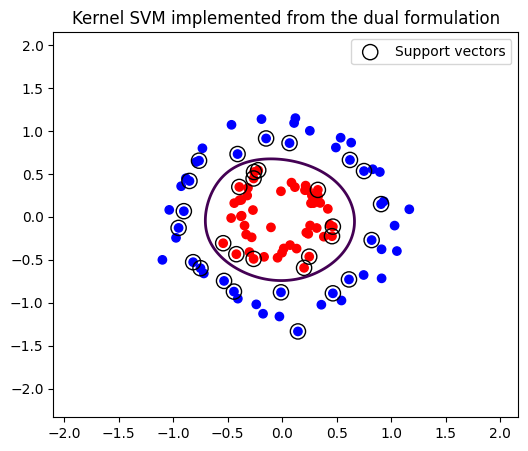

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.datasets import make_circles
from sklearn.svm import SVC

# ==========================================================
# 1. Generate a nonlinear dataset
# ==========================================================

# Two concentric circles -> not linearly separable
X, y = make_circles(n_samples=100, noise=0.1, factor=0.4, random_state=0)

# Convert labels from {0,1} to {-1,+1}
y = 2*y - 1

n = len(y)

# ==========================================================
# 2. Define the kernel function
# ==========================================================

def rbf_kernel(x, z, sigma=0.5):
    """
    Gaussian (RBF) kernel.

    k(x,z) = exp(-||x-z||^2 / (2 sigma^2))
    """
    return np.exp(-np.linalg.norm(x - z)**2 / (2*sigma**2))


# ==========================================================
# 3. Compute the kernel (Gram) matrix
# ==========================================================

K = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        K[i, j] = rbf_kernel(X[i], X[j])


# ==========================================================
# 4. Define the dual SVM objective function
# ==========================================================

def objective(alpha):
    """
    Dual objective function of SVM.

    maximize:
        sum(alpha_i)
        - 1/2 sum_{i,j} alpha_i alpha_j y_i y_j k(x_i,x_j)

    scipy minimizes -> we return the negative
    """

    term1 = np.sum(alpha)

    term2 = 0.5 * np.sum(
        (alpha[:, None] * alpha[None, :]) *
        (y[:, None] * y[None, :]) *
        K
    )

    return -(term1 - term2)


# ==========================================================
# 5. Optimization constraints
# ==========================================================

C = 1.0

# box constraints: 0 <= alpha_i <= C
bounds = [(0, C) for _ in range(n)]

# initial guess
alpha0 = np.zeros(n)

# run optimizer
result = minimize(objective, alpha0, bounds=bounds)

alpha = result.x


# ==========================================================
# 6. Identify support vectors
# ==========================================================

# support vectors have alpha_i > 0
sv = alpha > 1e-5

alpha_sv = alpha[sv]
X_sv = X[sv]
y_sv = y[sv]


# ==========================================================
# 7. Decision function
# ==========================================================

def decision_function(x):
    """
    f(x) = sum alpha_i y_i k(x,x_i)
    """
    s = 0
    for a, xi, yi in zip(alpha_sv, X_sv, y_sv):
        s += a * yi * rbf_kernel(x, xi)
    return s


# ==========================================================
# 8. Plot decision boundary
# ==========================================================

xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = np.array([decision_function(p) for p in grid])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))

# decision boundary
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# training points
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")

# highlight support vectors
plt.scatter(
    X_sv[:,0],
    X_sv[:,1],
    s=120,
    facecolors='none',
    edgecolors='black',
    label="Support vectors"
)

plt.title("Kernel SVM implemented from the dual formulation")
plt.legend()
plt.show()


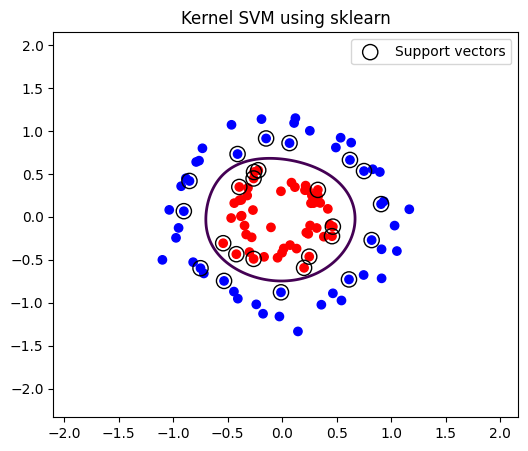

In [4]:
# ==========================================================
# 9. Compare with sklearn implementation
# ==========================================================

model = SVC(kernel="rbf", C=1.0, gamma=1/(2*0.5**2))
model.fit(X, y)

Z = model.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))

plt.contour(xx, yy, Z, levels=[0], linewidths=2)
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr")

plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='black',
    label="Support vectors"
)

plt.title("Kernel SVM using sklearn")
plt.legend()
plt.show()

## 3. Logistic Regression

Logistic regression is a **supervised machine learning algorithm** used for **binary classification problems**, where the goal is to predict which of two possible classes an observation belongs to.

Typical labels are $y \in \{0,1\}$ or sometimes $y \in \{-1,1\}$.

Unlike linear regression, which predicts a real-valued output, logistic regression predicts the **probability that an observation belongs to the positive class**.

---

#### The Model

The model assumes that the **log-odds** of the positive class is a linear function of the input features.

- Let $x \in \mathbb{R}^d$ be the feature vector.

- Logistic regression models the *conditional* probability $P(y=1 \mid x)$ using the **logistic (sigmoid) function**
$$
\sigma(z) = \frac{1}{1+e^{-z}}.
$$

- The model is therefore
$$
P(y=1\mid x) = \sigma(w^\top x + b),
$$

where
- $w \in \mathbb{R}^d$ is the parameter vector
- $b \in \mathbb{R}$ is the bias term.

---
Logistic regression has a natural **probabilistic interpretation**.

For each observation $y_i \sim \text{Bernoulli}(p_i)$, where
$$
p_i = \sigma(w^\top x_i + b).
$$

Thus, assuming independence, the conditional distribution of $y_i$ given $x_i$ is
$$
P(y_i \mid x_i; w,b)
= p_i^{y_i}(1-p_i)^{1-y_i}.
$$

This makes logistic regression a **conditional probabilistic model**.

---

Assuming the observations are independent, the likelihood of the dataset is

$$
L(w,b)
=
\prod_{i=1}^{n}
p_i^{y_i}(1-p_i)^{1-y_i}.
$$

Taking the logarithm gives the **log-likelihood**

$$
\ell(w,b)
=
\sum_{i=1}^{n}
\left[
y_i \log p_i
+
(1-y_i)\log(1-p_i)
\right].
$$

Model parameters are estimated by **maximum likelihood estimation (MLE)**.

---

#### Loss Function

Maximizing the log-likelihood is equivalent to **minimizing the negative log-likelihood**, which is called the **logistic loss** or **cross-entropy loss**.

$$
\mathcal{L}(w,b)
=
-
\sum_{i=1}^{n}
\left[
y_i \log p_i
+
(1-y_i)\log(1-p_i)
\right].
$$

In practice, regularization is often added:

$$
\mathcal{L}(w,b)
=
-
\sum_{i=1}^{n}
\left[
y_i \log p_i
+
(1-y_i)\log(1-p_i)
\right]
+
\lambda \|w\|^2
$$
which can be interpreted from a Bayesian perspective as **maximum a posteriori (MAP) estimation** with Gaussian prion distribution.

This helps prevent overfitting.

---

#### Decision Rule

Although the model predicts probabilities, classification is typically performed by thresholding:
$$
\hat y =
\begin{cases}
1 & \text{if } P(y=1\mid x) \ge 0.5 \\
0 & \text{otherwise}.
\end{cases}
$$

The decision boundary corresponds to
$$
w^\top x + b = 0,
$$

which is a **linear separating surface**.

---

#### Applications

Logistic regression is widely used across many fields because of its simplicity, interpretability, and probabilistic foundation.

Typical applications include:

- **Email filtering:** Identifying whether an email is **spam or not spam**.

- **Medicine and epidemiology:** Predicting the **risk of developing a disease**, such as diabetes or coronary heart disease, based on patient characteristics (age, sex, BMI, blood test results, etc.).

- **Political science:** Predicting voting behavior, for example whether a voter will vote for a particular political party based on demographic and socioeconomic factors.

- **Engineering reliability:** Predicting the **probability of system or component failure** in engineering processes.

- **Marketing:** Estimating the **probability that a customer will purchase a product**, renew a subscription, or churn.

- **In Economics and finance examples include:**
    * predicting whether a person participates in the labor force,
    * estimating the probability that a homeowner **defaults on a mortgage**.

(Logistic regression applications summarized from Wikipedia.)

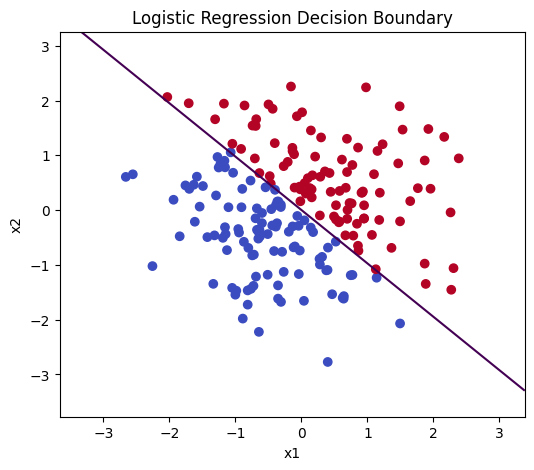

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helper function: logistic (sigmoid) function
# ---------------------------------------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =========================================================
# 1. Standard Logistic Regression (linear decision boundary)
# =========================================================

np.random.seed(0)

# Generate synthetic 2D dataset
n = 200
X = np.random.randn(n, 2)

# Define labels using a linear rule
# Points above the line x1 + x2 = 0 belong to class 1
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Add bias term to the design matrix
X_design = np.hstack([X, np.ones((n, 1))])

# Initialize parameters
w = np.zeros(3)
learning_rate = 0.1

# Train logistic regression using gradient descent
for _ in range(2000):

    # Linear model
    z = X_design @ w

    # Predicted probabilities
    p = sigmoid(z)

    # Gradient of the log-loss
    grad = X_design.T @ (p - y) / n

    # Parameter update
    w -= learning_rate * grad


# ---------------------------------------------------------
# Visualization of the decision boundary
# ---------------------------------------------------------

# Create a grid over the input space
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Add bias to grid points
grid_design = np.hstack([grid, np.ones((grid.shape[0],1))])

# Compute predicted probabilities on the grid
probs = sigmoid(grid_design @ w)
probs = probs.reshape(xx.shape)

plt.figure(figsize=(6,5))

# Plot training data
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

# Plot decision boundary (probability = 0.5)
plt.contour(xx, yy, probs, levels=[0.5])

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

## 4. Kernel Logistic Regression

Standard logistic regression assumes that the decision boundary is **linear in the input features**:
$$
P(y=1 \mid x) = \sigma(w^\top x + b).
$$

However, many classification problems require **nonlinear decision boundaries**.  
Kernel logistic regression extends logistic regression by allowing the model to learn **nonlinear functions of the input variables** while retaining the probabilistic framework.

The key idea is to map the data into a higher-dimensional feature space and perform logistic regression there.

---
Let $\phi : \mathbb{R}^d \rightarrow \mathcal{H}$ be a feature map into a (possibly high- or infinite-dimensional) feature space $\mathcal{H}$.

Logistic regression is then applied in this space:

$$
P(y=1 \mid x)
=
\sigma\!\left(
w^\top \phi(x) + b
\right).
$$

The corresponding loss function becomes

$$
\mathcal{L}(w,b)
=
-
\sum_{i=1}^{n}
\left[
y_i \log p_i
+
(1-y_i)\log(1-p_i)
\right]
+
\lambda \|w\|^2,
$$

where $p_i = \sigma(w^\top \phi(x_i)+b)$.

---

For regularized empirical risk minimization problems of this form, the **representer theorem** states that the optimal parameter vector can be expressed as a linear combination of the mapped training points:

$$
w
=
\sum_{i=1}^{n}
\alpha_i \phi(x_i).
$$

Substituting this representation into the model gives

$$
w^\top \phi(x)
=
\sum_{i=1}^{n}
\alpha_i
\langle \phi(x_i),\phi(x)\rangle.
$$

---

**Kernel Trick:** Define the **kernel function** $k(x,x') = \langle \phi(x),\phi(x') \rangle$.

This allows the model to be written without explicitly computing the feature map:

$$
P(y=1 \mid x)
=
\sigma
\left(
\sum_{i=1}^{n}
\alpha_i k(x_i,x) + b
\right).
$$

Thus the classifier depends only on **kernel evaluations between the new point and the training data**.

---

**Training**

Let $K$ denote the **kernel matrix** $K_{ij} = k(x_i,x_j)$.

Define

$$
f_i = \sum_{j=1}^{n} \alpha_j k(x_j,x_i).
$$

The optimization problem becomes

$$
\min_{\alpha}
-
\sum_{i=1}^{n}
\left[
y_i \log \sigma(f_i)
+
(1-y_i)\log(1-\sigma(f_i))
\right]
+
\lambda \alpha^\top K \alpha.
$$

This objective is **convex**, but unlike linear logistic regression it does not have a closed-form solution.

Typical optimization methods include:

- Newton's method
- Iteratively reweighted least squares (IRLS)
- gradient-based optimization.

---

For a new observation $x_*$, the predicted probability is

$$
P(y=1 \mid x_*)
=
\sigma
\left(
\sum_{i=1}^{n}
\alpha_i k(x_i,x_*) + b
\right).
$$

Thus the classifier is determined entirely by the training points and the kernel function.

---

#### Comparison with Kernel SVM

Kernel logistic regression is closely related to kernel support vector machines.

| | Kernel Logistic Regression | Kernel SVM |
|---|---|---|
| Loss | logistic loss | hinge loss |
| Output | class probability | margin score |
| Optimization | smooth convex | convex but non-smooth |
| Sparsity | typically dense | sparse (support vectors) |

Kernel SVM often produces sparse solutions, while kernel logistic regression generally uses **all training points** in the prediction function.

---

**Summary**

Kernel logistic regression combines

- the **probabilistic interpretation of logistic regression**
- the **nonlinear modeling power of kernel methods**.

The resulting classifier can model complex nonlinear decision boundaries while still providing **probabilistic predictions**.

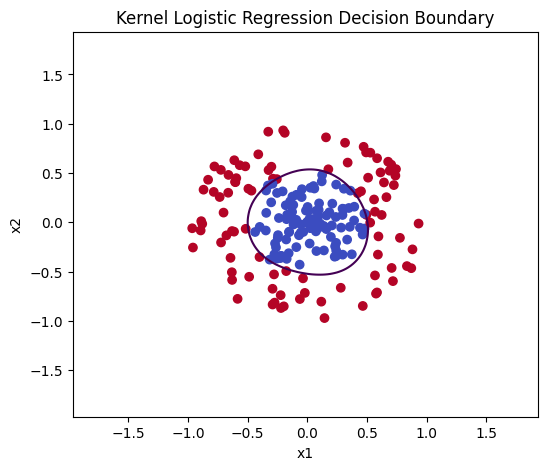

In [3]:
# =========================================================
# 2. Kernel Logistic Regression (RBF kernel)
# =========================================================

# Generate a nonlinear dataset: concentric circles
n = 200
theta = 2 * np.pi * np.random.rand(n)
r = np.random.rand(n)

X = np.zeros((n,2))
X[:,0] = r * np.cos(theta)
X[:,1] = r * np.sin(theta)

# Inner circle -> class 0, outer circle -> class 1
y = (r > 0.5).astype(int)


# ---------------------------------------------------------
# Radial Basis Function (Gaussian) kernel
# ---------------------------------------------------------

def rbf_kernel(X1, X2, gamma=5):

    # Compute squared Euclidean distance matrix
    sqdist = (
        np.sum(X1**2, axis=1).reshape(-1,1)
        + np.sum(X2**2, axis=1)
        - 2 * X1 @ X2.T
    )

    # Apply the RBF kernel
    return np.exp(-gamma * sqdist)


# Kernel matrix for training data
K = rbf_kernel(X, X)

# Dual parameters
alpha = np.zeros(n)

learning_rate = 0.5

# Train kernel logistic regression via gradient descent
for _ in range(3000):

    # Model output f(x_i)
    f = K @ alpha

    # Predicted probabilities
    p = sigmoid(f)

    # Gradient in dual representation
    grad = K @ (p - y) / n

    # Parameter update
    alpha -= learning_rate * grad


# ---------------------------------------------------------
# Visualization of nonlinear decision boundary
# ---------------------------------------------------------

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Compute kernel between grid points and training points
K_test = rbf_kernel(grid, X)

# Predict probabilities
f = K_test @ alpha
probs = sigmoid(f).reshape(xx.shape)

plt.figure(figsize=(6,5))

# Plot training data
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

# Nonlinear decision boundary
plt.contour(xx, yy, probs, levels=[0.5])

plt.title("Kernel Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

## 5. Kernel PCA

Kernel PCA is a nonlinear extension of principal component analysis that performs PCA in a high-dimensional feature space induced by a kernel function.

Let the training data be $x_1,\dots,x_n \in \mathbb{R}^d$, and let

$$
k(x,x')=\langle \phi(x),\phi(x') \rangle
$$

be a positive definite kernel associated with the feature map $\phi : \mathbb{R}^d \to \mathcal{H}$.

Instead of working explicitly with $\phi(x)$, the algorithm relies only on kernel evaluations.

Define the kernel matrix $K_{ij} = k(x_i,x_j)$, $i,j=1,\dots,n.$ This matrix corresponds to the Gram matrix of the mapped data:
$$
K_{ij} = \langle \phi(x_i), \phi(x_j) \rangle .
$$

---

### PCA in feature space

In feature space the covariance operator is
$$
C = \frac{1}{n}\sum_{i=1}^{n} \phi(x_i)\phi(x_i)^T .
$$

The principal components satisfy $C v = \lambda v$.

A key observation is that any eigenvector $v$ of $C$ lies in the span of the mapped samples:

$$
v = \sum_{i=1}^n \alpha_i \phi(x_i).
$$

Substituting this representation into the eigenvalue equation yields the dual eigenvalue problem
$$
K \alpha = n\lambda \alpha .
$$

Thus kernel PCA reduces to an eigenvalue decomposition of the $n\times n$ kernel matrix.

---

### Centering in feature space

PCA requires centered data. Since the feature vectors are not computed explicitly, centering must be performed directly on the kernel matrix.

Let $\mathbf{1}_n = \frac{1}{n}\mathbf{1}\mathbf{1}^T$.

The centered kernel matrix is

$$
K_c = K - \mathbf{1}_n K - K\mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n .
$$

The eigenvalue problem is then solved for $K_c$.

---

### Normalization of eigenvectors

The feature-space eigenvectors must satisfy $\|v\|^2 = 1$. Using $v = \sum_i \alpha_i \phi(x_i)$, this implies

$$
\alpha^T K \alpha = 1.
$$

In practice the normalized coefficients are

$$
\alpha_i \leftarrow \frac{\alpha_i}{\sqrt{\lambda}} .
$$

---

### Projection of a new point

For a new observation $x$, the projection onto the $m$-th principal component is

$$
\langle v_m , \phi(x) \rangle
=
\sum_{i=1}^n \alpha_i^{(m)} k(x,x_i).
$$

If centering was applied, the kernel values must also be centered with respect to the training data.

---

### Computational aspects

Kernel PCA requires the eigenvalue decomposition of the $n\times n$ Gram matrix, which leads to

- memory complexity $O(n^2)$
- time complexity $O(n^3)$

This becomes the main limitation for large datasets, motivating approximate methods (Nyström approximation, random features, sparse KPCA).

---

### Recent research directions

Several modern extensions of kernel PCA have appeared in recent years:

- **Interpretability methods**: new techniques extract feature importance from KPCA representations, helping interpret nonlinear components in high-dimensional biological data.  
- **Robust and sparse KPCA formulations**: optimization frameworks have been proposed that introduce sparsity and robustness while also reducing computational cost.  
- **Deep kernel PCA**: hierarchical variants combine multiple KPCA layers to extract multi-level latent representations.   

---

### Example modern applications

Kernel PCA is still widely used in applied ML pipelines:

- **industrial process monitoring and fault detection**, where nonlinear latent components capture complex system dynamics.  
- **high-dimensional biological data analysis**, including gene expression feature selection.  
- **time-series forecasting**, where nonlinear principal components serve as predictors.
- **analysis of deep learning models**: recent work shows that transformer self-attention can be interpreted through the lens of kernel PCA. 

### Python example: Kernel PCA on a nonlinear dataset

The following example illustrates how kernel PCA can reveal nonlinear structure in data that linear PCA cannot capture.

We generate a dataset consisting of **two concentric circles**. In the original space, the classes lie on two nonlinear manifolds. Linear PCA cannot separate them because it only finds directions of maximal *linear variance*. Kernel PCA, however, maps the data into a higher-dimensional feature space where the structure becomes linearly separable.

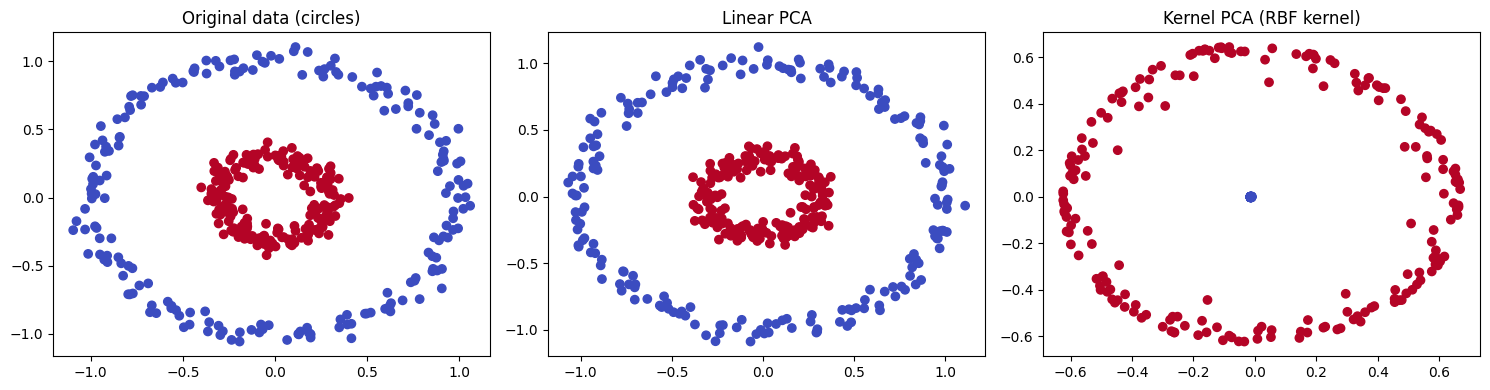

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA

# ------------------------------------------------------------
# Generate nonlinear dataset (two concentric circles)
# ------------------------------------------------------------

X, y = make_circles(
    n_samples=400,
    factor=0.3,
    noise=0.05,
    random_state=0
)

# ------------------------------------------------------------
# Linear PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ------------------------------------------------------------
# Kernel PCA (RBF kernel)
# ------------------------------------------------------------

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=15
)

X_kpca = kpca.fit_transform(X)

# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# original data
axes[0].scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
axes[0].set_title("Original data (circles)")

# linear PCA
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm")
axes[1].set_title("Linear PCA")

# kernel PCA
axes[2].scatter(X_kpca[:,0], X_kpca[:,1], c=y, cmap="coolwarm")
axes[2].set_title("Kernel PCA (RBF kernel)")

plt.tight_layout()
plt.show()

### Swiss roll example 

Another classic demonstration of nonlinear dimensionality reduction is the Swiss roll dataset. The data lie on a two-dimensional manifold embedded in three dimensions.

Linear PCA simply projects the data onto a plane, while nonlinear methods can reveal the intrinsic low-dimensional structure.

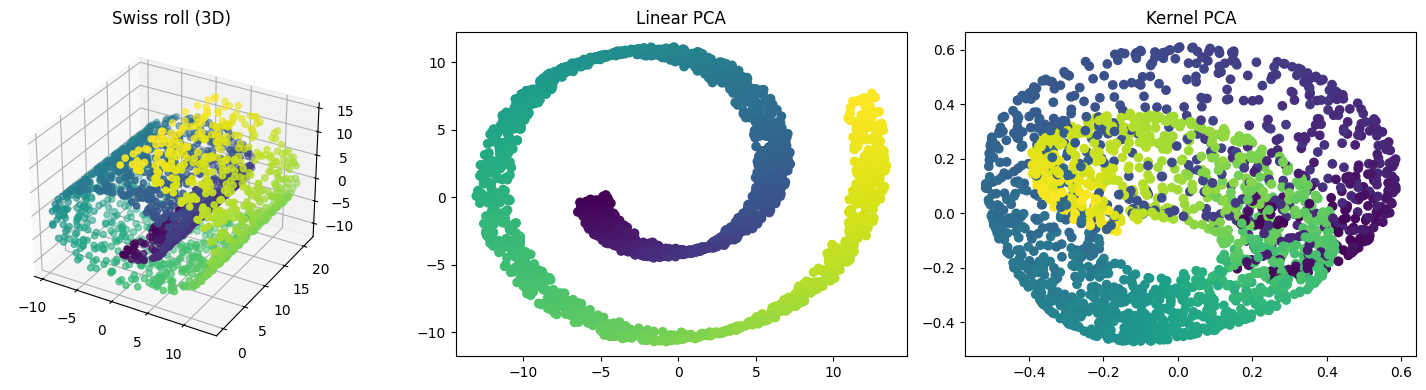

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA

# ------------------------------------------------------------
# Generate Swiss roll dataset
# ------------------------------------------------------------

X, t = make_swiss_roll(
    n_samples=2000,
    noise=0.05,
    random_state=0
)

# ------------------------------------------------------------
# Linear PCA
# ------------------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# ------------------------------------------------------------
# Kernel PCA
# ------------------------------------------------------------

kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.02
)

X_kpca = kpca.fit_transform(X)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(15,4))

# original 3D data
ax = fig.add_subplot(131, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], c=t)
ax.set_title("Swiss roll (3D)")

# PCA projection
ax = fig.add_subplot(132)
ax.scatter(X_pca[:,0], X_pca[:,1], c=t)
ax.set_title("Linear PCA")

# kernel PCA projection
ax = fig.add_subplot(133)
ax.scatter(X_kpca[:,0], X_kpca[:,1], c=t)
ax.set_title("Kernel PCA")

plt.tight_layout()
plt.show()

## 6. Gaussian Processes

### Normal (Gaussian) distribution

The **normal distribution** is one of the most important probability distributions in statistics.  
A random variable $X$ is normally distributed with mean $\mu$ and variance $\sigma^2$ if its density is

$$
p(x)=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\!\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

The mean $\mu$ determines the center of the distribution, while the variance $\sigma^2$ controls the spread.

In the multivariate case, $X \sim \mathcal N(\mu,\Sigma)$

where

- \(\mu\) is the mean vector
- \(\Sigma\) is the covariance matrix.

---

### Gaussian processes

A **Gaussian process (GP)** is a stochastic process $(X_t)_{t\ge 0}$ if for every finite set of points
$t_1,\dots,t_n$, the random vector

$$
(X_{t_1},\dots,X_{t_n})
$$

follows a multivariate normal distribution.

A Gaussian process is fully specified by two functions:

- the **mean function**: $m(t) = \mathbb E[X_t]$

- the **covariance function (kernel)**: $k(s,t) = \text{Cov}(X_s,X_t)$


We write $X \sim GP(m,k)$.

Intuitively:

- the mean function describes the average value of the function
- the covariance function describes how function values at different inputs are correlated.

---

### Prior over functions

In many machine learning applications we assume a zero mean prior: $f \sim GP(0,k)$

This means $\mathbb E[f(x)] = 0$ and $\text{Cov}(f(x),f(x')) = k(x,x')$.

The kernel determines properties of the sampled functions such as

- smoothness
- periodicity
- length scale of variation.

---

### Noisy observations

Suppose we observe data $(x_1,y_1),\dots,(x_n,y_n)$ with additive Gaussian noise:
$$
y_i = f(x_i) + \varepsilon_i,
$$

where $\varepsilon_i \sim \mathcal N(0,\sigma^2)$.

Define

- $K$ as the kernel matrix $K_{ij} = k(x_i,x_j)$
  
- $k_* = (k(x_*,x_1),\dots,k(x_*,x_n))^T$

for a new input $x_*$.

---

### Posterior distribution

One of the key properties of Gaussian processes is that conditioning a Gaussian process on observed data again yields a Gaussian process.

The predictive distribution at $x_*$ is therefore Gaussian:
$$
f(x_*) \mid \mathcal D
\sim
\mathcal N(m(x_*),\, v(x_*))
$$

where 

- the posterior mean is
$$
m(x_*) =
k_*^T (K + \sigma^2 I)^{-1} y,
$$

- and the posterior variance is
$$
v(x_*) =
k(x_*,x_*)
-
k_*^T (K + \sigma^2 I)^{-1} k_*.
$$

---

### Interpretation

The posterior mean provides the best estimate of the unknown function, while the posterior variance quantifies uncertainty.

Important properties:

- predictions are **linear combinations of kernel evaluations**
- uncertainty increases far from training points
- the kernel controls smoothness and correlation structure.

---

### Connection to kernel ridge regression

The posterior mean of a Gaussian process with Gaussian noise is exactly the solution of **kernel ridge regression**.

Indeed,
$$
m(x_*) =
k_*^T (K + \sigma^2 I)^{-1} y
$$

has the same form as the prediction function obtained in kernel ridge regression.

Thus Gaussian processes can be interpreted as a **Bayesian version of kernel regression**, where instead of estimating a single function we infer a full probability distribution over functions.

#### Gaussian Process Regression: Posterior Mean and Uncertainty

This example demonstrates **Gaussian Process Regression (GPR)** on a small synthetic dataset.  
The goal is to illustrate how Gaussian processes produce both

- a **predictive mean**, and
- an **uncertainty estimate**.

## Problem Setup

We assume that the unknown function follows a Gaussian process prior $f \sim GP(0,k)$,
where $k$ is the covariance kernel.

The observations are assumed to be noisy:

$$
y_i = f(x_i) + \varepsilon_i,
\quad
\varepsilon_i \sim \mathcal N(0,\sigma^2)
$$

The kernel used in this example is the **Radial Basis Function (RBF)** kernel:

$$
k(x,x') =
\sigma_f^2
\exp
\left(
-\frac{(x-x')^2}{2\ell^2}
\right)
$$

The experiment proceeds as follows:

1. Generate a small set of **training inputs**.
2. Evaluate a true function (here $f(x)=\sin(x)$).
3. Add Gaussian noise to obtain observations.
4. Compute the **Gaussian process posterior**.


The resulting plot shows:

- the **true function**
- the **posterior mean**
- a **confidence band (±2 standard deviations)**
- the **training observations**

Key observations:

- The uncertainty is **small near training data**.
- The uncertainty **increases away from observed points**.
- The GP provides both predictions and calibrated uncertainty estimates.

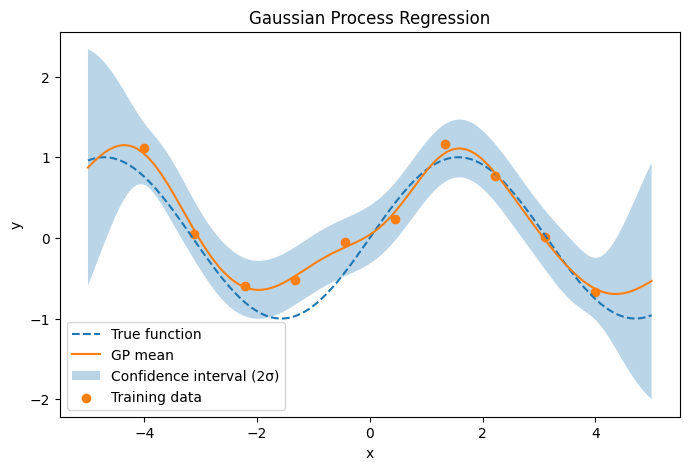

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Squared Exponential (RBF) kernel
# -----------------------------------------------------------

def rbf_kernel(X1, X2, length_scale=1.0, sigma_f=1.0):
    """
    Compute the RBF (squared exponential) kernel matrix.

    k(x,x') = sigma_f^2 * exp( - ||x-x'||^2 / (2*l^2) )
    """

    X1 = X1.reshape(-1,1)
    X2 = X2.reshape(-1,1)

    sqdist = (X1 - X2.T)**2

    return sigma_f**2 * np.exp(-0.5 / length_scale**2 * sqdist)


# -----------------------------------------------------------
# Generate training data
# -----------------------------------------------------------

np.random.seed(0)

# Training inputs
X_train = np.linspace(-4,4,10)

# True function
def f(x):
    return np.sin(x)

# Noisy observations
y_train = f(X_train) + 0.2*np.random.randn(len(X_train))


# -----------------------------------------------------------
# Compute Gaussian Process posterior
# -----------------------------------------------------------

# Test points where we want predictions
X_test = np.linspace(-5,5,200)

# Kernel matrices
K = rbf_kernel(X_train, X_train)          # covariance of training points
K_s = rbf_kernel(X_train, X_test)         # covariance train-test
K_ss = rbf_kernel(X_test, X_test)         # covariance test-test

# Add noise variance to training covariance
noise_var = 0.04
K += noise_var * np.eye(len(X_train))

# Compute inverse
K_inv = np.linalg.inv(K)

# Posterior mean
mu = K_s.T @ K_inv @ y_train

# Posterior covariance
cov = K_ss - K_s.T @ K_inv @ K_s

# Standard deviation (uncertainty)
std = np.sqrt(np.diag(cov))


# -----------------------------------------------------------
# Plot results
# -----------------------------------------------------------

plt.figure(figsize=(8,5))

# True function
plt.plot(X_test, f(X_test), linestyle="--", label="True function")

# GP mean prediction
plt.plot(X_test, mu, label="GP mean")

# Confidence interval (±2 standard deviations)
plt.fill_between(
    X_test,
    mu - 2*std,
    mu + 2*std,
    alpha=0.3,
    label="Confidence interval (2σ)"
)

# Training observations
plt.scatter(X_train, y_train, label="Training data")

plt.title("Gaussian Process Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

### Gaussian Process Regression: Prior and Posterior Function Samples

This simulation illustrates the interpretation of a **Gaussian process as a distribution over functions**.

The experiment consists of two stages:

1. Sampling functions from the **Gaussian process prior**
2. Sampling functions from the **posterior after observing data**

Sampling from the prior means drawing functions from the multivariate Gaussian

$$
f(X) \sim \mathcal N(0, K)
$$

where $K_{ij}=k(x_i,x_j)$.

These samples correspond to **random smooth functions**.

**Conditioning on Data**

After observing training data $(X, y)$, the Gaussian process is conditioned on these observations.

The posterior distribution at new points is

$$
f_* \mid X,y
\sim
\mathcal N(\mu_*,\Sigma_*)
$$

with

$$
\mu_* =
K_*^T K^{-1} y
$$

and

$$
\Sigma_* =
K_{**} - K_*^T K^{-1} K_*.
$$

**GP Prior:**
- Functions are **random but smooth**
- There is **no constraint from data**

**GP Posterior:**
- Functions **pass near observed data points**
- Uncertainty is **small near data**
- Uncertainty **increases away from observations**

This illustrates the key idea behind Gaussian processes:

> A Gaussian process defines a probability distribution over functions, which becomes constrained once observations are incorporated.

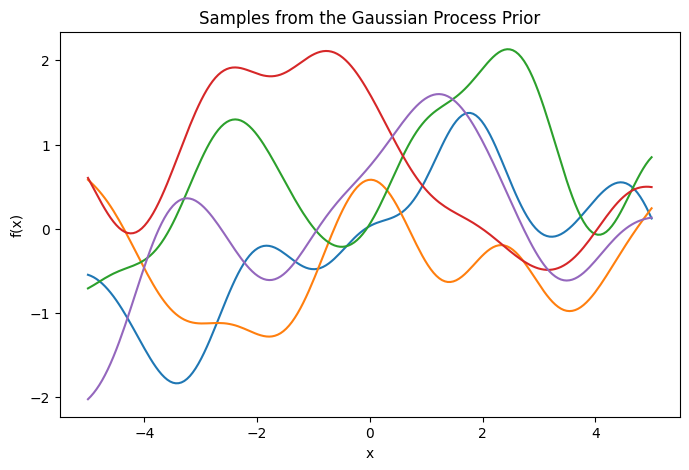

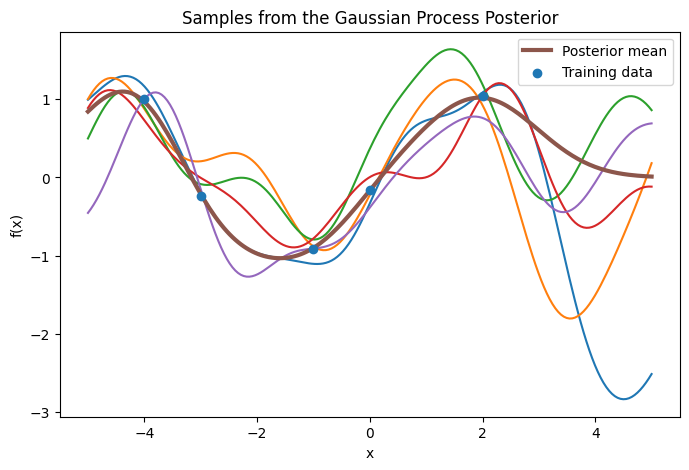

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# RBF (squared exponential) kernel
# -----------------------------------------------------------

def rbf_kernel(X1, X2, length_scale=1.0, sigma_f=1.0):
    """
    Radial Basis Function kernel

    k(x,x') = sigma_f^2 * exp(-||x-x'||^2 / (2 l^2))
    """

    X1 = X1.reshape(-1,1)
    X2 = X2.reshape(-1,1)

    sqdist = (X1 - X2.T)**2

    return sigma_f**2 * np.exp(-0.5 * sqdist / length_scale**2)


# -----------------------------------------------------------
# Points where we evaluate the GP
# -----------------------------------------------------------

X = np.linspace(-5,5,200)

# Kernel matrix for these points
K = rbf_kernel(X, X)

# Add a tiny numerical jitter for stability
K += 1e-8 * np.eye(len(X))


# -----------------------------------------------------------
# Sample functions from the GP PRIOR
# -----------------------------------------------------------

# Mean function (zero mean GP)
mean = np.zeros(len(X))

# Draw random functions from the prior distribution
prior_samples = np.random.multivariate_normal(mean, K, 5)

plt.figure(figsize=(8,5))

for s in prior_samples:
    plt.plot(X, s)

plt.title("Samples from the Gaussian Process Prior")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.show()


# -----------------------------------------------------------
# Generate some training data
# -----------------------------------------------------------

np.random.seed(1)

X_train = np.array([-4,-3,-1,0,2])
y_train = np.sin(X_train) + 0.15*np.random.randn(len(X_train))


# -----------------------------------------------------------
# Compute the GP posterior
# -----------------------------------------------------------

# Kernel matrices
K = rbf_kernel(X_train, X_train)
K_s = rbf_kernel(X_train, X)
K_ss = rbf_kernel(X, X)

# Observation noise
noise_var = 0.02
K += noise_var * np.eye(len(X_train))

# Invert training covariance
K_inv = np.linalg.inv(K)

# Posterior mean
mu = K_s.T @ K_inv @ y_train

# Posterior covariance
cov = K_ss - K_s.T @ K_inv @ K_s

# -----------------------------------------------------------
# Sample functions from the GP POSTERIOR
# -----------------------------------------------------------

posterior_samples = np.random.multivariate_normal(mu, cov, 5)

plt.figure(figsize=(8,5))

# Plot posterior samples
for s in posterior_samples:
    plt.plot(X, s)

# Plot posterior mean
plt.plot(X, mu, linewidth=3, label="Posterior mean")

# Plot training observations
plt.scatter(X_train, y_train, zorder=3, label="Training data")

plt.title("Samples from the Gaussian Process Posterior")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

plt.show()

### 7. Nyström Approximation

Kernel methods require storing and manipulating the matrix

$$
K \in \mathbb{R}^{n \times n}
$$

which can be computationally expensive.

The Nyström method approximates $K$ using a subset of $m \ll n$ landmark points.

**Partition**

Select $m$ columns:

$$
K =
\begin{pmatrix}
W & C^T \\
C & *
\end{pmatrix}
$$

where

- $W$ is an $m \times m$ matrix
- $C$ contains cross-kernel values.

**Approximation**

$$
K \approx C W^{-1} C^T
$$

This produces a **low-rank approximation** of the kernel matrix.

Applications include

- scalable kernel ridge regression
- scalable SVM
- large-scale kernel PCA.

#### Example: Nyström Approximation of RBF Kernel

The goal is to approximate a large kernel matrix by subsampling, thereby reduce the computation cost.

Original full RBF kernel for 200 points → dense 200x200 matrix.

Nyström approximation using only 30 landmark points → approximate kernel of the same size but cheaper to compute in practice.

Error measurement shows how good the approximation is.

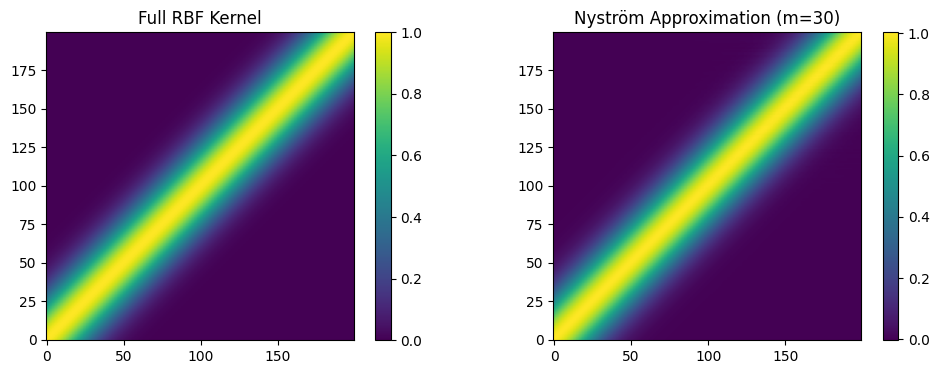

Relative Frobenius norm error: 0.0018


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Nyström Approximation of RBF Kernel
# ==========================================================

# ----------------------------------------------------------
# Problem Description
# ----------------------------------------------------------
"""
Nyström approximation is a technique to approximate a large kernel matrix K using a small subset of columns.

Given a kernel matrix K of size n x n and a subset of m << n columns:
    K ≈ C W^† C^T
where
    - C is the n x m submatrix of K (columns corresponding to sampled points)
    - W is the m x m intersection of selected columns and rows
    - W^† is the pseudo-inverse of W

This reduces storage and computation from O(n^2) to O(n m).

Here, we demonstrate Nyström approximation using an RBF kernel on synthetic 1D data.
"""

# ----------------------------------------------------------
# Generate synthetic data
# ----------------------------------------------------------

np.random.seed(0)
n = 200  # total data points
X = np.linspace(-5,5,n).reshape(-1,1)

# RBF kernel function
def rbf_kernel(X1, X2, gamma=0.5):
    sqdist = (X1 - X2.T)**2
    return np.exp(-gamma * sqdist)

# Full kernel (for comparison)
K_full = rbf_kernel(X, X)

# ----------------------------------------------------------
# Nyström Approximation
# ----------------------------------------------------------

m = 30  # number of landmark points
indices = np.random.choice(n, m, replace=False)
X_landmarks = X[indices]

# Submatrices
C = rbf_kernel(X, X_landmarks)         # n x m
W = rbf_kernel(X_landmarks, X_landmarks) # m x m

# Pseudo-inverse of W
W_inv = np.linalg.pinv(W)

# Approximate kernel
K_nystrom = C @ W_inv @ C.T

# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(K_full, origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Full RBF Kernel")

plt.subplot(1,2,2)
plt.imshow(K_nystrom, origin='lower', cmap='viridis')
plt.colorbar()
plt.title(f"Nyström Approximation (m={m})")

plt.show()

# ----------------------------------------------------------
# Optional: compute approximation error
# ----------------------------------------------------------
error = np.linalg.norm(K_full - K_nystrom, 'fro') / np.linalg.norm(K_full, 'fro')
print(f"Relative Frobenius norm error: {error:.4f}")

## 8. Neural Tangent Kernel (NTK)

Neural Tangent Kernels (NTKs) establish a formal connection between **deep neural networks** and **kernel methods**.

#### Linearization of a Neural Network

Consider a neural network with parameters $\theta$:

$$
f(x; \theta)
$$

We can perform a **first-order Taylor expansion around initialization** $\theta_0$:

$$
f(x; \theta) \approx f(x; \theta_0) + \nabla_\theta f(x; \theta_0)^T (\theta - \theta_0)
$$

This linear approximation maps training dynamics to a **kernel machine**.

#### Definition of NTK

The **Neural Tangent Kernel** is defined as the inner product of parameter gradients at initialization:

$$
k_{NTK}(x, x') = \nabla_\theta f(x; \theta_0)^T \nabla_\theta f(x'; \theta_0)
$$

It measures **how similar two inputs are in terms of their influence on the network output**.

#### Key Properties

- **Infinite-width limit**: As the width of the network layers goes to infinity, the NTK **becomes deterministic and fixed**.
- **Gradient descent equivalence**: Training the network with gradient descent is equivalent to performing **kernel regression using $k_{NTK}$**.
- **Wide network behavior**: Very wide networks **behave like kernel machines**, learning functions in the Reproducing Kernel Hilbert Space (RKHS) defined by the NTK.

#### Implications

1. Provides a theoretical framework to analyze **optimization and generalization** in deep networks.
2. Explains why **very wide networks** can be effectively linear during training.
3. Enables **exact predictions of training dynamics** for networks of large width.

#### References / Further Reading

- Jacot, Gabriel, Franck Gabriel, and Clément Hongler. *Neural Tangent Kernel: Convergence and Generalization in Neural Networks*. NeurIPS 2018.
- Lee, Jaehoon, et al. *Wide Neural Networks of Any Depth Evolve as Linear Models Under Gradient Descent*. NeurIPS 2019.

In [10]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install --upgrade "jax[cpu]"Add

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 MB 25.7 MB/s  0:00:03 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 26.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 27.1 MB/s  0:00:00 eta 0:00:010:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 19.7 MB/s  0:00:010.7 MB/s eta 0:00:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:m╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
      Successfully uninstalled numpy-1.26.44m╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
  Attempting uninstall: scipy0m╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
    Found existing installation: scipy 1.11.4╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/6 [numpy]
    Uninstalling scipy-1.11.4:━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/6 [scipy]py]
      Successfully uninstalled scipy-1.11.47m╺━━━━━━━━━━━━━━━━━━━━━━━━━

### Neural Tangent Kernel: 1D Regression

This example demonstrates how the **Neural Tangent Kernel (NTK)** can be used to perform regression on a simple 1D dataset.

#### Setup

- **Data**: 1D points `X_train` with noisy targets `y_train = sin(X_train) + noise`.
- **Network**: 1-hidden-layer MLP with 50 ReLU units.
- **NTK computation**: Using `neural-tangents` library, we compute the kernel at initialization.

#### NTK Kernel Regression

1. Compute the NTK on training data:

$$
K = NTK(X_{train}, X_{train})
$$

2. Add regularization: $K + \lambda I$.
3. Solve for alpha: $\alpha = (K + \lambda I)^{-1} y_{train}$.
4. Predict on test points: $y_{pred} = NTK(X_{test}, X_{train}) \cdot \alpha$.

#### Visualization

- **Red points**: training data  
- **Blue curve**: NTK kernel regression prediction  
- **Green dashed curve**: true function \(f(x) = \sin(x)\)  

This illustrates how **gradient descent on a wide MLP is approximated by NTK regression**.

In [12]:
# -----------------------------------------------------------
# Neural Tangent Kernel Simulation for a simple MLPAdd
# -----------------------------------------------------------

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
import neural_tangents as nt
from neural_tangents import stax  # Neural network library for NTK

# -----------------------------------------------------------
# 1. Generate synthetic 1D data
# -----------------------------------------------------------

np.random.seed(0)
X_train = np.linspace(-5,5,20)[:,None]  # shape (20,1)
y_train = jnp.sin(X_train)

X_test = np.linspace(-6,6,200)[:,None]

# -----------------------------------------------------------
# 2. Define a simple MLP network
# -----------------------------------------------------------

# 1 hidden layer, 50 units, ReLU activation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(50), stax.Relu(),
    stax.Dense(1)
)

# -----------------------------------------------------------
# 3. Compute NTK
# -----------------------------------------------------------

# The NTK is computed for training points
K_train = kernel_fn(X_train, X_train, 'ntk')  # shape (n_train, n_train)

# Regularization term for stability
lambda_reg = 1e-6
K_train_reg = K_train + lambda_reg * jnp.eye(len(X_train))

# Compute the inverse
K_inv = jnp.linalg.inv(K_train_reg)

# NTK kernel regression: alpha = K^{-1} y
alpha = K_inv @ y_train

# Predict on test points
K_test = kernel_fn(X_test, X_train, 'ntk')  # shape (n_test, n_train)
y_pred = K_test @ alpha

# -----------------------------------------------------------
# 4. Visualization
# -----------------------------------------------------------

plt.figure(figsize=(8,5))

# Training points
plt.scatter(X_train, y_train, color='red', label='Training data')

# NTK kernel regression prediction
plt.plot(X_test, y_pred, color='blue', label='NTK Kernel Regression')

# True function
plt.plot(X_test, jnp.sin(X_test), color='green', linestyle='--', label='True function')

plt.title("Neural Tangent Kernel Regression (1-hidden-layer MLP)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

RuntimeError: This version of jaxlib was built using AVX instructions, which your CPU and/or operating system do not support. You may be able work around this issue by building jaxlib from source.

### Neural Tangent Kernel: 2D Classification

This example demonstrates the **Neural Tangent Kernel** applied to a 2D classification problem.

#### Setup

- **Data**: 2D points arranged in two classes: inner circle vs outer circle.  
- **Network**: 2-hidden-layer MLP, 50 ReLU units per layer, 1 output neuron.  
- **NTK computation**: `kernel_fn(X, X, 'ntk')` at initialization.  

#### NTK Kernel Regression for Classification

1. Compute the NTK on training data $K = NTK(X, X)$.  
2. Regularize: $K + \lambda I$.  
3. Solve for alpha: $\alpha = (K + \lambda I)^{-1} y$.  
4. Predict on a 2D grid: $y_{pred} = NTK(grid, X) \cdot \alpha$.  

#### Visualization

- **Contour plot**: predicted NTK values across the 2D grid → shows the **decision boundary**.  
- **Scatter points**: original training data colored by class.  

This demonstrates how **wide neural networks behave like kernel machines** during training, and how the **NTK defines the function space** the network explores.

In [8]:
# =========================================================
# 2D Classification with Neural Tangent Kernel
# =========================================================

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
import neural_tangents as nt
from neural_tangents import stax

# ---------------------------------------------------------
# 1. Generate synthetic 2D data: inner vs outer circle
# ---------------------------------------------------------

np.random.seed(0)
n = 200
theta = 2*np.pi*np.random.rand(n)
r = np.random.rand(n)

X = jnp.zeros((n,2))
X = X.at[:,0].set(r * np.cos(theta))
X = X.at[:,1].set(r * np.sin(theta))

y = (r > 0.5).astype(float)  # inner circle=0, outer circle=1

# ---------------------------------------------------------
# 2. Define a simple MLP
# ---------------------------------------------------------

# 2-layer MLP: 50 units each, ReLU activation
init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(50), stax.Relu(),
    stax.Dense(50), stax.Relu(),
    stax.Dense(1)
)

# ---------------------------------------------------------
# 3. Compute NTK
# ---------------------------------------------------------

K_train = kernel_fn(X, X, 'ntk')  # shape (n_train, n_train)

lambda_reg = 1e-6
K_train_reg = K_train + lambda_reg * jnp.eye(n)

K_inv = jnp.linalg.inv(K_train_reg)

alpha = K_inv @ y

# ---------------------------------------------------------
# 4. Make predictions on a grid
# ---------------------------------------------------------

xx, yy = jnp.meshgrid(jnp.linspace(-1.2,1.2,200), jnp.linspace(-1.2,1.2,200))
grid = jnp.c_[xx.ravel(), yy.ravel()]

K_test = kernel_fn(grid, X, 'ntk')
y_pred = K_test @ alpha
y_pred_grid = y_pred.reshape(xx.shape)

# ---------------------------------------------------------
# 5. Visualization
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

# Decision boundary
plt.contourf(xx, yy, y_pred_grid, levels=50, cmap='coolwarm', alpha=0.6)

# Training points
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k')

plt.title("Neural Tangent Kernel Decision Boundary (2D MLP)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

ModuleNotFoundError: No module named 'jax'

## 9. Paper reading